# DNATCO → graph → ML, end to end

End-to-end on the **RS25** RNA set (PDB ids in `data/RS25_RNA_c2.csv`):

1. **fetch** each structure's DNATCO "extended" mmCIF (`dnatco_fetch.py`)
2. **convert** to an rnaglib-format 2.5D graph JSON *with coordinates* (`dnatco_to_graph.py`)
3. **train** RNA base-pair models with a structure-level **train / val / test** split

**Tasks below:** (3) classify the Leontis–Westhof family of base pairs; (4) predict *which*
residues pair (contact, with a geometry ablation); (5) joint **detect + type**, selecting the
epoch on val and reporting the held-out **test** split; (6) per-structure spread (val vs test).

In [1]:
# auto-reload edited .py modules so kernel picks up script changes without a restart
%load_ext autoreload
%autoreload 2

import concurrent.futures as cf
import csv
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from dnatco_fetch import fetch_one
from dnatco_to_graph import dnatco_cif_to_graph
from train_pair_interactions import load_dataset, PairRGCN, run_epoch
from rnaglib.utils import dump_json

# dataset = the RS25 RNA set (PDB ids in data/RS25_RNA_c2.csv)
RS25_CSV = Path("../../../data/RS25_RNA_c2.csv")
CIFS = Path("rs25/cifs"); CIFS.mkdir(parents=True, exist_ok=True)
GRAPHS = Path("rs25/graphs"); GRAPHS.mkdir(parents=True, exist_ok=True)

/Users/cw_liao/na-hackathon-2026/workstreams/ws1-annotation-validation/mmcif-to-pyg/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Fetch the RS25 structures (DNATCO)

Read the RS25 PDB ids from the CSV and download each one's DNATCO coordinate mmCIF
(cached: re-runs skip files already on disk).

In [2]:
ids = sorted({r[0].strip().lower() for r in csv.reader(open(RS25_CSV)) if r and r[0].strip()})
with cf.ThreadPoolExecutor(max_workers=12) as ex:
    results = list(ex.map(lambda p: fetch_one(p, CIFS, False), ids))
print("RS25 ids:", len(ids), "| fetch status:", dict(Counter(s.split('_')[0] for _, s in results)))
print("cif files on disk:", len(list(CIFS.glob('*.cif'))))

RS25 ids: 738 | fetch status: {'skip': 738}
cif files on disk: 738


## 2. Convert to graph JSON

In [3]:
ok = 0
for cif in sorted(CIFS.glob('*.cif')):
    try:
        G = dnatco_cif_to_graph(cif)
        if G.number_of_nodes():
            dump_json(str(GRAPHS / f'{cif.stem}.json'), G)
            ok += 1
    except Exception as e:
        print(cif.name, 'failed:', e)
print(f'wrote {ok} graphs')

# peek at one graph
G = dnatco_cif_to_graph(next(CIFS.glob('*.cif')))
lw = Counter(d['LW'] for *_, d in G.edges(data=True))
print('example graph:', G.graph['pdbid'], '| nodes', G.number_of_nodes(),
      '| edge types', dict(lw))

wrote 738 graphs
example graph: 5hby | nodes 13 | edge types {'B53': 12, 'B35': 12, 'cWW': 8}


## 3. Train the RGCN to classify base-pair interactions

For each base pair, predict its Leontis–Westhof family (18-way multi-class).

Because cWW is ~75% of pairs, plain (micro) accuracy is misleading. We report the
**honest, imbalance-aware metrics**:
- **micro acc** — overall fraction correct (inflated by cWW)
- **balanced acc** — mean per-class recall (each LW family weighted equally)
- **macro-F1** — mean per-class F1
- **non-canonical recall** — base-aware: family-typing accuracy on the genuinely
  non-canonical pairs, i.e. everything except canonical Watson–Crick (cWW *and* A·U/G·C).
  Note a `cWW_U-U` counts as non-canonical here (cWW geometry, but not a WC pair).

In [4]:
data_list, lw_vocab = load_dataset(GRAPHS)
gen = torch.Generator().manual_seed(0)
perm = torch.randperm(len(data_list), generator=gen).tolist()
n_val = max(1, len(data_list) // 5)
val = [data_list[i] for i in perm[:n_val]]
train = [data_list[i] for i in perm[n_val:]] or val

counts = Counter()
for d in train:
    counts.update(d.pair_y.tolist())
baseline = max(counts.values()) / sum(counts.values())   # majority (micro) baseline

model = PairRGCN(num_classes=len(lw_vocab))
model._inv_vocab = {v: k for k, v in lw_vocab.items()}   # base-aware non-canonical recall (cWW + A-U/G-C)
opt = torch.optim.Adam(model.parameters(), lr=1e-2)

hist = []
for epoch in range(1, 31):
    run_epoch(model, train, train=True, optimizer=opt, batch_size=32, gen=gen, device='cpu')
    va = run_epoch(model, val, train=False, optimizer=opt, batch_size=32, gen=gen, device='cpu')
    hist.append((epoch, va['micro_acc'], va['balanced_acc'], va['macro_f1'], va['noncanonical_recall']))
    print(f"epoch {epoch:2d}  micro {va['micro_acc']:.3f}  balanced {va['balanced_acc']:.3f}  "
          f"macro-F1 {va['macro_f1']:.3f}  non-canon {va['noncanonical_recall']:.3f}")
print(f"\n{len(data_list)} graphs | {len(lw_vocab)} LW classes | majority baseline {baseline:.3f}")

epoch  1  micro 0.764  balanced 0.056  macro-F1 0.048  non-canon 0.400
epoch  2  micro 0.764  balanced 0.056  macro-F1 0.048  non-canon 0.400
epoch  3  micro 0.764  balanced 0.056  macro-F1 0.048  non-canon 0.400
epoch  4  micro 0.764  balanced 0.056  macro-F1 0.048  non-canon 0.400
epoch  5  micro 0.782  balanced 0.109  macro-F1 0.105  non-canon 0.455
epoch  6  micro 0.822  balanced 0.209  macro-F1 0.198  non-canon 0.555
epoch  7  micro 0.840  balanced 0.284  macro-F1 0.274  non-canon 0.610
epoch  8  micro 0.848  balanced 0.339  macro-F1 0.328  non-canon 0.632
epoch  9  micro 0.849  balanced 0.366  macro-F1 0.356  non-canon 0.644
epoch 10  micro 0.862  balanced 0.382  macro-F1 0.379  non-canon 0.660
epoch 11  micro 0.868  balanced 0.401  macro-F1 0.407  non-canon 0.674
epoch 12  micro 0.870  balanced 0.414  macro-F1 0.421  non-canon 0.683
epoch 13  micro 0.870  balanced 0.405  macro-F1 0.409  non-canon 0.680
epoch 14  micro 0.876  balanced 0.434  macro-F1 0.457  non-canon 0.694
epoch 

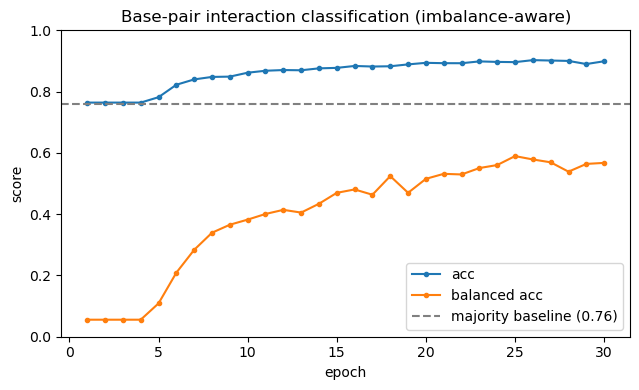

In [14]:
ep, micro, bal, f1, nc = zip(*hist)
plt.figure(figsize=(6.5, 4))
plt.plot(ep, micro, '-o', ms=3, label='acc')
plt.plot(ep, bal, '-o', ms=3, label='balanced acc')
plt.axhline(baseline, ls='--', c='gray', label=f'majority baseline ({baseline:.2f})')
plt.xlabel('epoch'); plt.ylabel('score'); plt.ylim(0, 1)
plt.legend(); plt.title('Base-pair interaction classification (imbalance-aware)')
plt.tight_layout(); plt.show()

## 4. Predict which residues pair — and does geometry help? (ablation)

A second task (`train_contact_prediction.py`): for a pair of nucleotides, predict
whether they **base-pair** (contact / link prediction), using the experimental
geometry now stored in the graphs (`xyz_C1p`/`xyz_glyN`/`xyz_P`).

- message passing: **backbone only** (base-pair edges are the labels, so they're hidden)
- geometry as rotation/translation-invariant features: C1′–C1′, glyN–glyN, P–P distances + seq separation
- **hard negatives**: spatially-close non-pairs (via KD-tree), so distance alone can't solve it

**Ablation:** we train the *same* model twice — **with** vs **without** the geometric
features — and compare to a distance-only baseline (pair iff C1′–C1′ ≤ 12.5 Å). This
shows whether the experimental coordinates actually help the model learn.

In [6]:
import train_contact_prediction as cp   # separate module; avoids name clashes with section 3

# graphs must contain coordinates (section 2 includes them by default)
cdata = cp.load_dataset(GRAPHS, neg_ratio=1.0, cutoff=18.0, seed=0)
assert cdata, "No coord-bearing graphs found — re-run section 2 so graphs include coordinates."

cgen = torch.Generator().manual_seed(0)
cperm = torch.randperm(len(cdata), generator=cgen).tolist()
cnv = max(1, len(cdata) // 5)
cval = [cdata[i] for i in cperm[:cnv]]
ctrain = [cdata[i] for i in cperm[cnv:]] or cval

base = cp.distance_baseline(cval)   # predict pair iff C1'-C1' <= 12.5 A
print(f"distance-only baseline:  F1 {base['f1']:.3f}  (P {base['precision']:.3f}  R {base['recall']:.3f})\n")

# ablation: identical setup, only toggle the geometric features
curves = {}
for use_geom in (True, False):
    g = torch.Generator().manual_seed(0)            # same data order/sampling for a fair comparison
    cmodel = cp.ContactGNN(use_geom=use_geom)
    copt = torch.optim.Adam(cmodel.parameters(), lr=5e-3)
    f1s = []
    for epoch in range(1, 21):
        cp.run_epoch(cmodel, ctrain, train=True, optimizer=copt, batch_size=16, gen=g, device='cpu')
        m = cp.run_epoch(cmodel, cval, train=False, optimizer=copt, batch_size=16, gen=g, device='cpu')
        f1s.append(m['f1'])
    curves[use_geom] = f1s
    print(f"{'with geometry' if use_geom else 'no geometry (seq+backbone)':28s} final F1 {f1s[-1]:.3f}")

print(f"\ngeometry gives +{curves[True][-1] - curves[False][-1]:.3f} F1 over sequence+backbone only")

[contact] skipped 101 graphs (no coords or no pairs)


distance-only baseline:  F1 0.837  (P 0.733  R 0.975)

with geometry                final F1 0.897
no geometry (seq+backbone)   final F1 0.789

geometry gives +0.108 F1 over sequence+backbone only


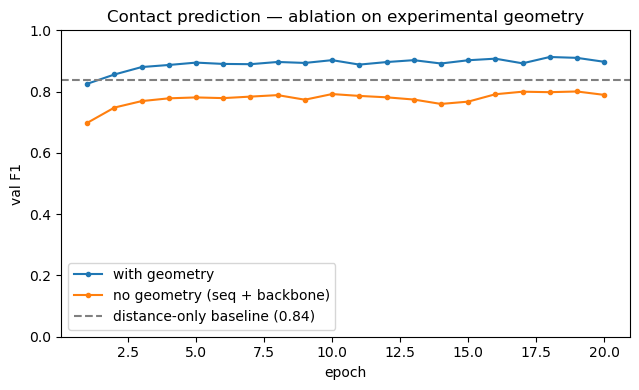

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6.5, 4))
epochs = range(1, len(curves[True]) + 1)
plt.plot(epochs, curves[True], '-o', ms=3, label='with geometry')
plt.plot(epochs, curves[False], '-o', ms=3, label='no geometry (seq + backbone)')
plt.axhline(base['f1'], ls='--', c='gray', label=f"distance-only baseline ({base['f1']:.2f})")
plt.xlabel('epoch'); plt.ylabel('val F1'); plt.ylim(0, 1)
plt.legend(); plt.title('Contact prediction — ablation on experimental geometry')
plt.tight_layout(); plt.show()

## 5. Detect *and* type base pairs — train / val / test

The unified model (`train_pair_detect_type.py`): for each candidate pair predict one of
**NONE / cWW / tWS / cSH / …** — find the pairs **and** name their Leontis–Westhof family in one
shot (backbone + geometry as input, base-pair edges hidden).

We split RS25 by structure into **train / val / test (70 / 15 / 15)**, pick the epoch by
validation detection-F1, then report on the held-out **test** split:
1. detection F1, exact (detect+type), typing | detected;
2. **per-class** precision/recall/F1 on test;
3. one **test** structure: true vs predicted family table + arc diagram.

In [8]:
import copy
import train_pair_detect_type as dt   # joint detect + type model

ddata, class_names, dfiles = dt.load_dataset(GRAPHS, neg_ratio=1.0, cutoff=18.0, seed=0)
dgen = torch.Generator().manual_seed(0)
dperm = torch.randperm(len(ddata), generator=dgen).tolist()
n = len(ddata); n_test = int(round(0.15 * n)); n_val = int(round(0.15 * n))
te_i, va_i, tr_i = dperm[:n_test], dperm[n_test:n_test + n_val], dperm[n_test + n_val:]
dtrain = [ddata[i] for i in tr_i]
dval = [ddata[i] for i in va_i];  dval_files = [dfiles[i] for i in va_i]
dtest = [ddata[i] for i in te_i]; dtest_files = [dfiles[i] for i in te_i]

dmodel = dt.PairTypeGNN(num_classes=len(class_names))
dopt = torch.optim.Adam(dmodel.parameters(), lr=5e-3)
best_f1, best_state = -1.0, None
for epoch in range(1, 31):
    dt.run_epoch(dmodel, dtrain, train=True, optimizer=dopt, batch_size=16, gen=dgen, device='cpu')
    vm = dt.run_epoch(dmodel, dval, train=False, optimizer=dopt, batch_size=16, gen=dgen, device='cpu')
    if vm['det_F1'] > best_f1:                       # model selection on validation
        best_f1, best_state = vm['det_F1'], copy.deepcopy(dmodel.state_dict())
dmodel.load_state_dict(best_state)                   # restore best-val checkpoint

conf = dt.confusion(dmodel, dtest)                   # evaluate on the held-out TEST split
m = dt.metrics_from_confusion(conf)
print(f"{len(ddata)} graphs -> train {len(dtrain)} / val {len(dval)} / test {len(dtest)} "
      f"| {len(class_names)} classes")
print(f"best val detection F1 {best_f1:.3f}")
print(f"TEST: detection F1 {m['det_F1']:.3f}  |  exact (detect+type) {m['exact_acc']:.3f}  "
      f"|  typing | detected {m['type_acc_given_detected']:.3f}")

[detect+type] skipped 101 graphs (no coords or no pairs)


637 graphs -> train 445 / val 96 / test 96 | 19 classes
best val detection F1 0.884
TEST: detection F1 0.903  |  exact (detect+type) 0.839  |  typing | detected 0.935


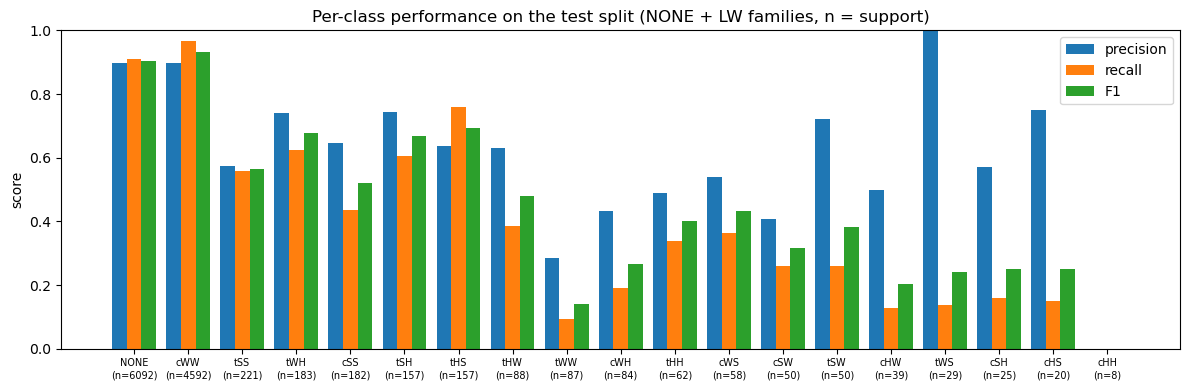

In [9]:
import numpy as np
prec, rec, f1, sup = dt.per_class_prf(conf)
order = [i for i in np.argsort(-sup.numpy()) if sup[i] > 0]   # classes present in val, by support
xs = np.arange(len(order)); w = 0.27
plt.figure(figsize=(12, 4))
plt.bar(xs - w, prec.numpy()[order], w, label='precision')
plt.bar(xs,     rec.numpy()[order],  w, label='recall')
plt.bar(xs + w, f1.numpy()[order],   w, label='F1')
plt.xticks(xs, [f"{class_names[i]}\n(n={int(sup[i])})" for i in order], fontsize=7)
plt.ylabel('score'); plt.ylim(0, 1); plt.legend()
plt.title('Per-class performance on the test split (NONE + LW families, n = support)')
plt.tight_layout(); plt.show()

Test example 8zau: 69 nt, 26 true pairs, 52 candidate pairs scored


,pair,true,pred,ok
26,C11-A44,cSW,cSW,OK
27,A9-A46,cWS,NONE,x
28,A21-U28,cWW,cWW,OK
29,A48-U61,cWW,cWW,OK
30,A51-U58,cWW,cWW,OK
31,C11-G41,cWW,NONE,x
32,C16-G33,cWW,cWW,OK
33,C17-G32,cWW,cWW,OK
34,C18-G31,cWW,cWW,OK
35,C19-G30,cWW,cWW,OK


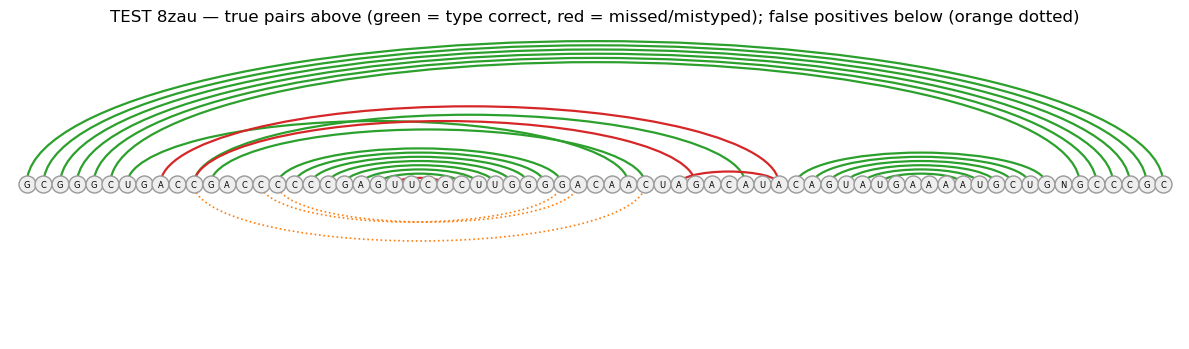

In [10]:
import numpy as np, pandas as pd
from matplotlib.patches import Arc
from IPython.display import display

# representative single-chain TEST structure: enough pairs, detection recall near the median
cands = []
for k in range(len(dtest)):
    _, lab, ch, _ = dt.graph_node_order(dtest_files[k])
    if len(set(ch)) == 1 and 10 <= len(lab) <= 90 and int(dtest[k].pair_y.gt(0).sum()) >= 5:
        pk = dt.predict_one(dmodel, dtest[k]); pos = dtest[k].pair_y > 0
        cands.append((float((pk[pos] > 0).sum()) / int(pos.sum()), k))   # detection recall
cands.sort()
ex = cands[len(cands) // 2][1] if cands else 0

pid, labels, chains, seqs = dt.graph_node_order(dtest_files[ex])
pred = dt.predict_one(dmodel, dtest[ex])
pi = dtest[ex].pair_index.numpy(); y = dtest[ex].pair_y.numpy()

rows = [{"pair": f"{labels[pi[0, c]]}-{labels[pi[1, c]]}",
         "true": class_names[int(y[c])], "pred": class_names[int(pred[c])],
         "ok": "OK" if y[c] == pred[c] else "x"} for c in range(pi.shape[1])]
df = pd.DataFrame(rows).sort_values(["true", "pair"]).reset_index(drop=True)
print(f"Test example {pid}: {len(labels)} nt, {int((y > 0).sum())} true pairs, {len(y)} candidate pairs scored")
display(df[df.true != "NONE"].head(20))          # the real base pairs and how the model called them

# arc diagram: true pairs above (green=type correct, red=missed/mistyped); false positives below
xpos = {i: k for k, i in enumerate(sorted(range(len(labels)), key=lambda i: seqs[i]))}
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.plot([0, len(labels) - 1], [0, 0], color="#bbb", lw=1, zorder=0)
for i in range(len(labels)):
    ax.scatter([xpos[i]], [0], s=150, color="#eee", edgecolors="#999", zorder=3)
    ax.text(xpos[i], 0, labels[i][0], ha="center", va="center", fontsize=6, zorder=4)
for c in range(pi.shape[1]):
    a, b = sorted((xpos[pi[0, c]], xpos[pi[1, c]])); w = b - a; t, p = int(y[c]), int(pred[c])
    if t > 0:
        ax.add_patch(Arc(((a + b) / 2, 0), w, w * 0.6, theta1=0, theta2=180,
                         color="#2ca02c" if t == p else "#d62728", lw=1.6, zorder=2))
    elif p > 0:
        ax.add_patch(Arc(((a + b) / 2, 0), w, w * 0.6, theta1=180, theta2=360,
                         color="#ff7f0e", lw=1.2, ls=":", zorder=2))
ax.set_xlim(-1, len(labels)); ax.set_ylim(-len(labels) * 0.32, len(labels) * 0.32); ax.axis("off")
ax.set_title(f"TEST {pid} — true pairs above (green = type correct, red = missed/mistyped); "
             f"false positives below (orange dotted)")
plt.tight_layout(); plt.show()